# Facebook Ads Data Analysis

This notebook analyzes Facebook advertising campaign data using Pandas, Matplotlib, and Seaborn.  
The analysis includes daily performance trends, campaign-based comparisons, ROMI distribution, correlation analysis, and a regression plot.

### Task 1: Daily Advertising Performance in 2021
### Task 2: Campaign-Based Advertising Performance
### Task 3: Daily ROMI Distribution by Campaign
### Task 4: ROMI Distribution
### Task 5: Correlation Heatmap
### Task 6: Linear Regression Plot

## Task 1: Daily Grouping and 2021 Performance Charts

In this task, the dataset is filtered for the year 2021 and grouped by the `ad_date` column.  
The goal is to visualize daily advertising performance by showing:

- Daily total ad spend in 2021
- Daily ROMI in 2021
- 7-day rolling averages for ad spend and ROMI as a bonus task

The `total_spend` column is aggregated using sum, while the `romi` column is aggregated using mean.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [38]:
df = pd.read_csv("facebook_ads_data (2.0).csv")

df.head()

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


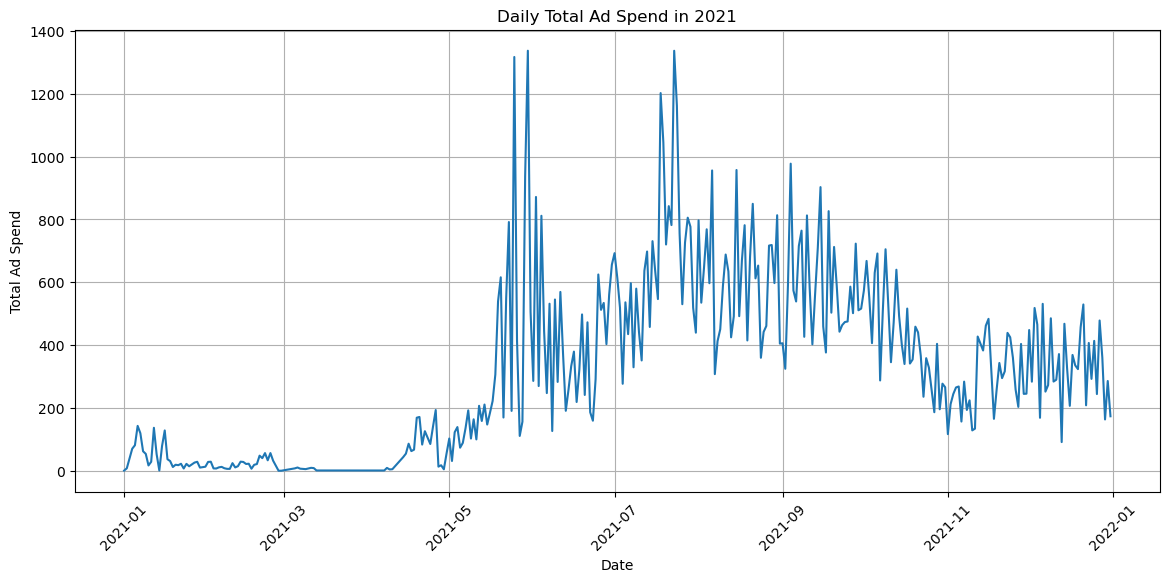

In [39]:
df["ad_date"] = pd.to_datetime(df["ad_date"])

daily_spend_2021 = (
    df[(df["ad_date"] >= "2021-01-01") & (df["ad_date"] <= "2021-12-31")]
    .groupby("ad_date", as_index=False)["total_spend"]
    .sum()
)

plt.figure(figsize=(14, 6))
plt.plot(daily_spend_2021["ad_date"], daily_spend_2021["total_spend"])

plt.title("Daily Total Ad Spend in 2021")
plt.xlabel("Date")
plt.ylabel("Total Ad Spend")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

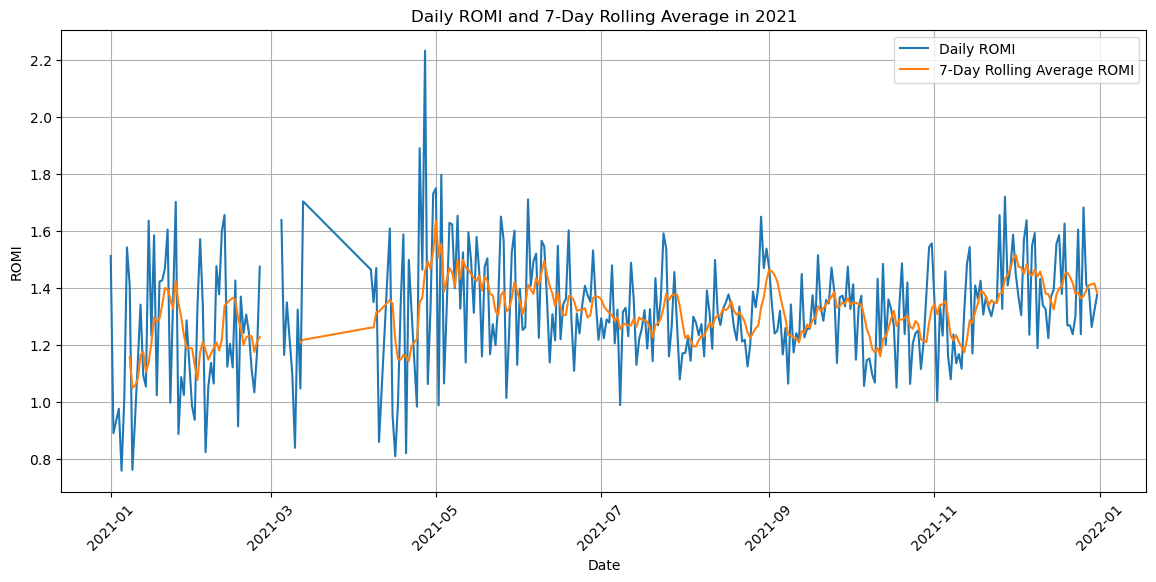

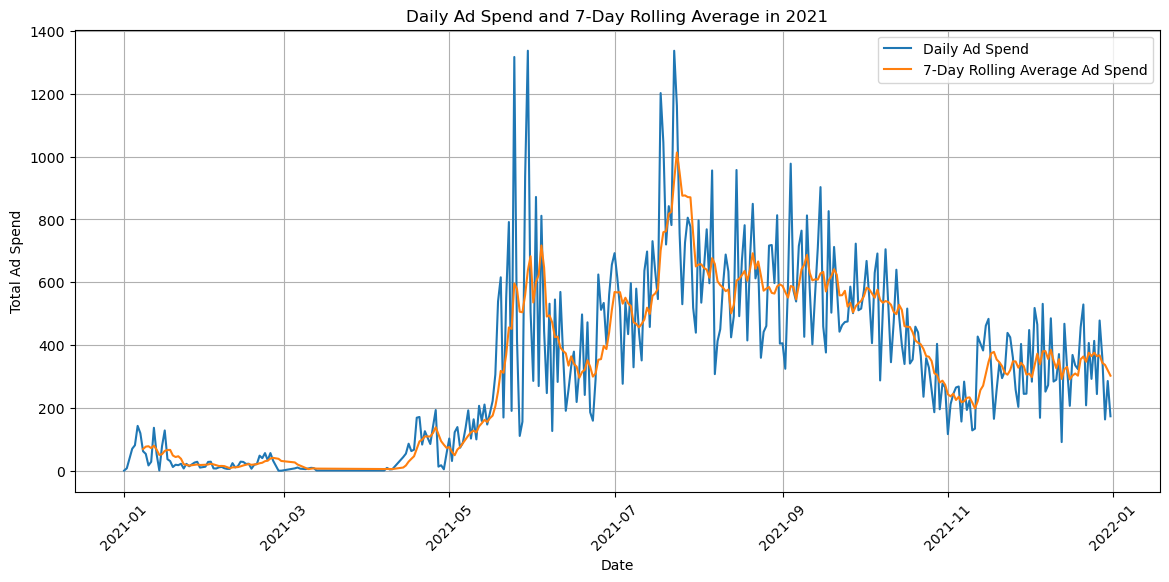

In [40]:
df["ad_date"] = pd.to_datetime(df["ad_date"])

daily_2021 = (
    df[(df["ad_date"] >= "2021-01-01") & (df["ad_date"] <= "2021-12-31")]
    .groupby("ad_date", as_index=False)
    .agg({
        "total_spend": "sum",
        "romi": "mean"
    })
)

daily_2021["spend_rolling_7"] = daily_2021["total_spend"].rolling(window=7).mean()
daily_2021["romi_rolling_7"] = daily_2021["romi"].rolling(window=7).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_2021["ad_date"], daily_2021["romi"], label="Daily ROMI")
plt.plot(daily_2021["ad_date"], daily_2021["romi_rolling_7"], label="7-Day Rolling Average ROMI")
plt.title("Daily ROMI and 7-Day Rolling Average in 2021")
plt.xlabel("Date")
plt.ylabel("ROMI")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(daily_2021["ad_date"], daily_2021["total_spend"], label="Daily Ad Spend")
plt.plot(daily_2021["ad_date"], daily_2021["spend_rolling_7"], label="7-Day Rolling Average Ad Spend")
plt.title("Daily Ad Spend and 7-Day Rolling Average in 2021")
plt.xlabel("Date")
plt.ylabel("Total Ad Spend")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Task 2: Campaign-Based Advertising Performance

In this section, the data is grouped by campaign name.  
The first chart shows the total advertising spend for each campaign.

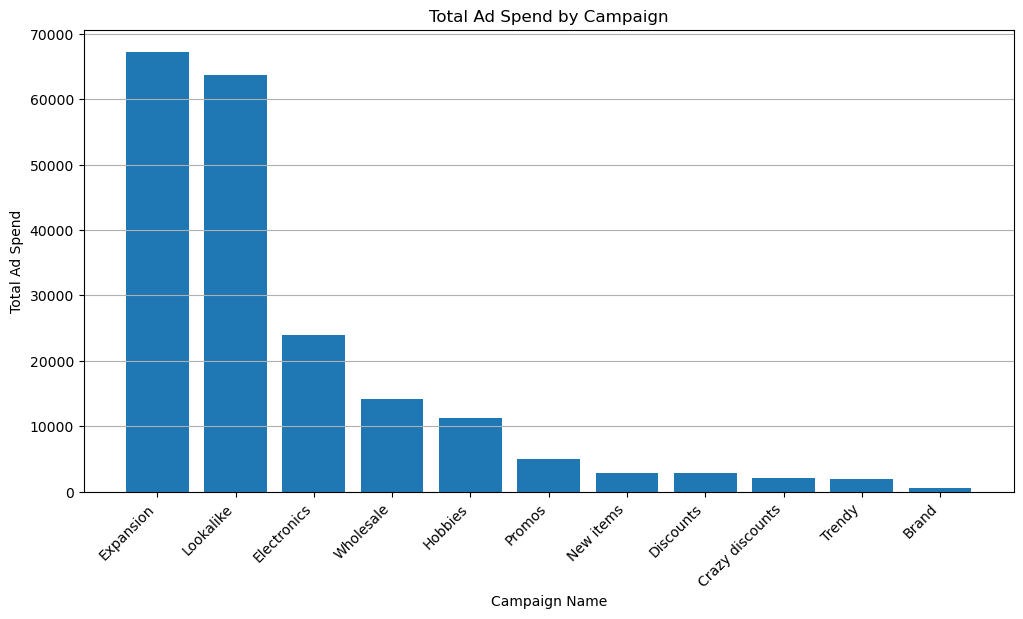

In [41]:
campaign_spend = (
    df.groupby("campaign_name", as_index=False)["total_spend"]
    .sum()
    .sort_values("total_spend", ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(
    campaign_spend["campaign_name"],
    campaign_spend["total_spend"]
)

plt.title("Total Ad Spend by Campaign")
plt.xlabel("Campaign Name")
plt.ylabel("Total Ad Spend")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

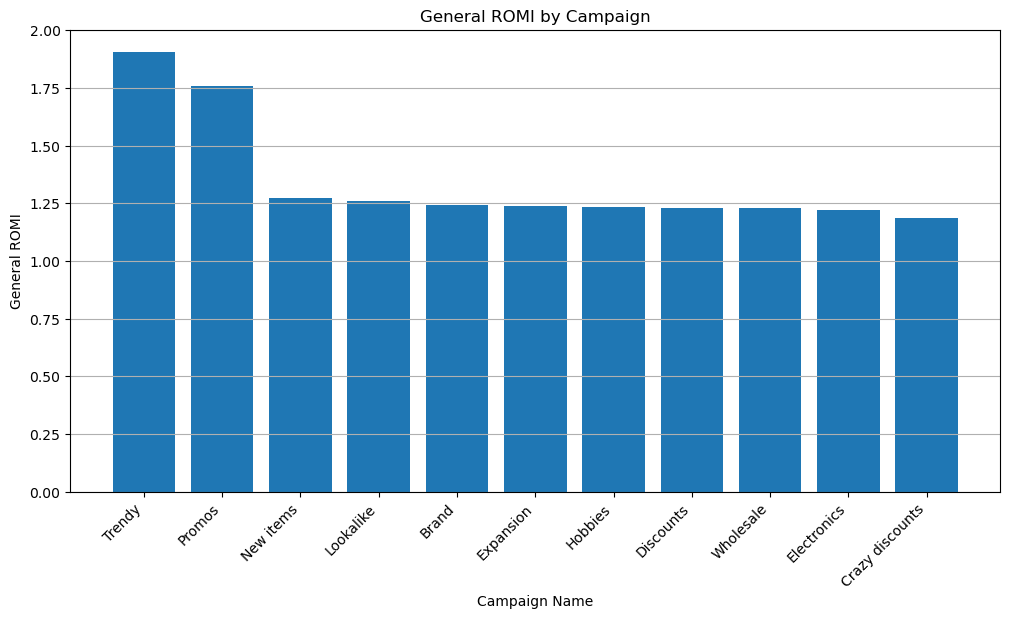

In [42]:
campaign_romi = (
    df.groupby("campaign_name", as_index=False)
    .agg({
        "total_spend": "sum",
        "total_value": "sum"
    })
)

campaign_romi["general_romi"] = campaign_romi["total_value"] / campaign_romi["total_spend"]

campaign_romi = campaign_romi.sort_values("general_romi", ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    campaign_romi["campaign_name"],
    campaign_romi["general_romi"]
)

plt.title("General ROMI by Campaign")
plt.xlabel("Campaign Name")
plt.ylabel("General ROMI")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

## Task 3: Daily ROMI Distribution by Campaign

This section uses a box plot to show how daily ROMI values are distributed for each campaign.

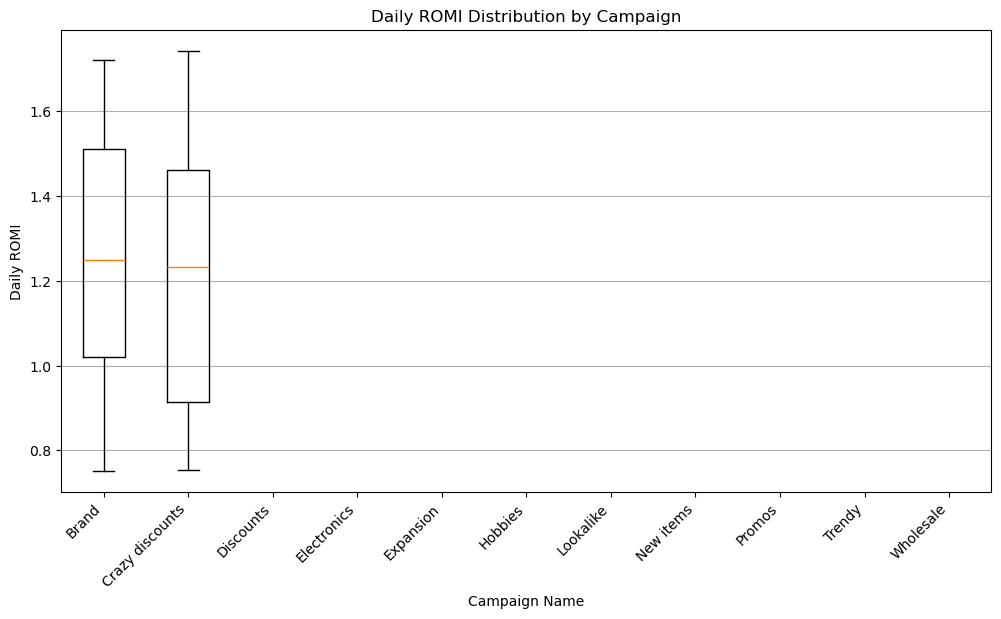

In [44]:
df["ad_date"] = pd.to_datetime(df["ad_date"])

daily_campaign_romi = (
    df.groupby(["campaign_name", "ad_date"], as_index=False)["romi"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.boxplot(
    [
        daily_campaign_romi[daily_campaign_romi["campaign_name"] == campaign]["romi"]
        for campaign in daily_campaign_romi["campaign_name"].unique()
    ],
    tick_labels=daily_campaign_romi["campaign_name"].unique()
)

plt.title("Daily ROMI Distribution by Campaign")
plt.xlabel("Campaign Name")
plt.ylabel("Daily ROMI")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

plt.show()

## Task 4: ROMI Distribution

This section shows the distribution of ROMI values in the dataset using a histogram.

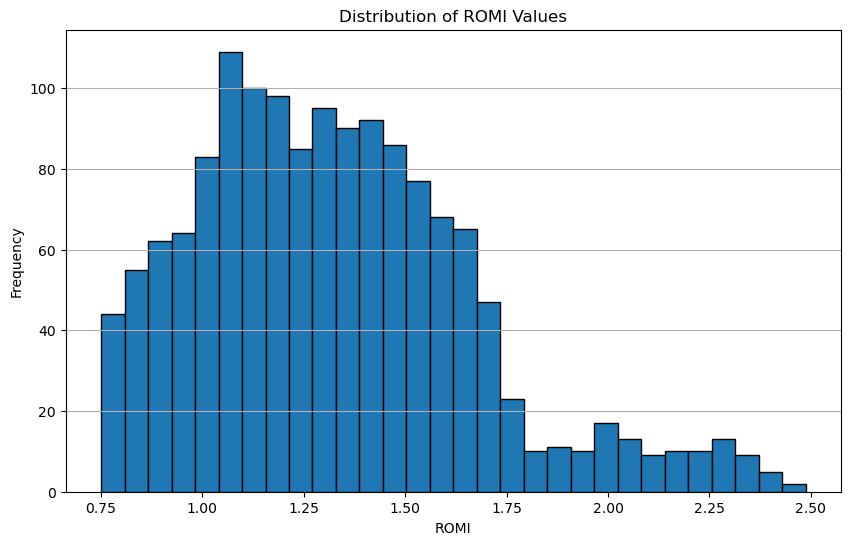

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(df["romi"], bins=30, edgecolor="black")

plt.title("Distribution of ROMI Values")
plt.xlabel("ROMI")
plt.ylabel("Frequency")
plt.grid(axis="y")

plt.show()

## Task 5: Correlation Heatmap

This section analyzes the correlation between all numerical metrics in the dataset.  
A heatmap is used to visualize the relationships between the variables.  
The strongest and weakest correlations are also identified, especially the factors related to `total_value`.

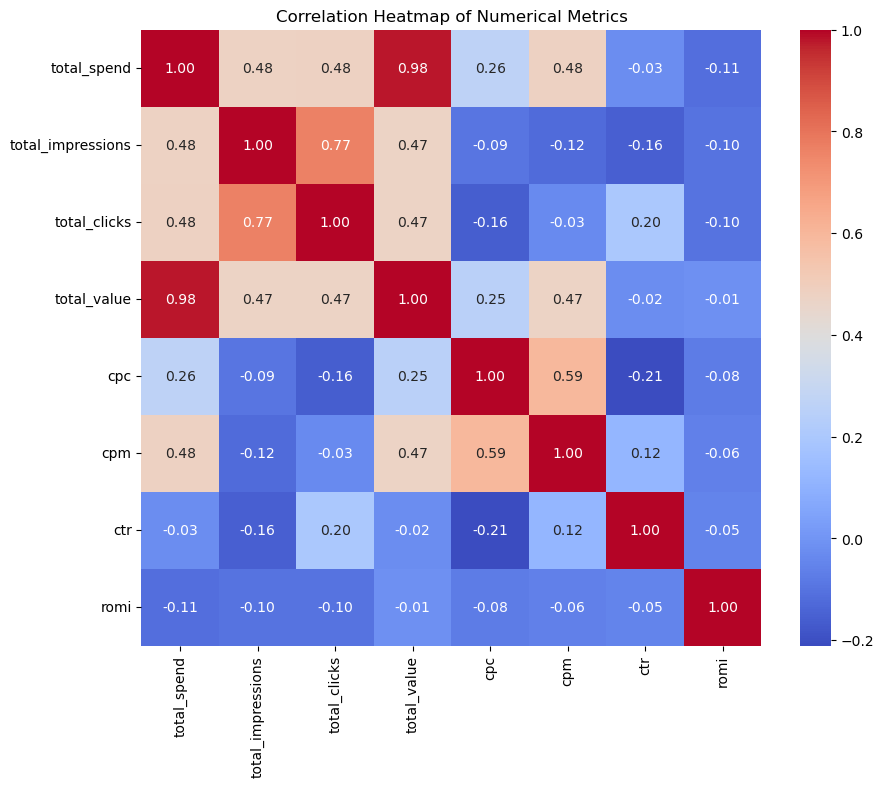

In [51]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Metrics")
plt.show()

In [52]:
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ["Metric 1", "Metric 2", "Correlation"]

highest_corr = corr_pairs.loc[corr_pairs["Correlation"].idxmax()]
lowest_corr = corr_pairs.loc[corr_pairs["Correlation"].idxmin()]

print("Highest correlation:")
print(highest_corr)

print("\nLowest correlation:")
print(lowest_corr)

print("\nCorrelation with total_value:")
print(
    correlation_matrix["total_value"]
    .drop("total_value")
    .sort_values(ascending=False)
)

Highest correlation:
Metric 1       total_spend
Metric 2       total_value
Correlation        0.97889
Name: 2, dtype: object

Lowest correlation:
Metric 1            cpc
Metric 2            ctr
Correlation   -0.210719
Name: 23, dtype: object

Correlation with total_value:
total_spend          0.978890
total_clicks         0.472124
total_impressions    0.472037
cpm                  0.471338
cpc                  0.250851
romi                -0.013733
ctr                 -0.022267
Name: total_value, dtype: float64


The strongest positive correlation with `total_value` is observed with `total_spend`.  
This means that higher advertising spend is strongly associated with higher total value.

`total_value` also has moderate positive relationships with `total_clicks`, `total_impressions`, and `cpm`.  
The relationship between `total_value` and `romi` is very weak, which means ROMI does not move strongly together with total value in this dataset.

## Task 6: Linear Regression Plot

This section visualizes the relationship between `total_spend` and `total_value` using a scatter plot with a linear regression line.

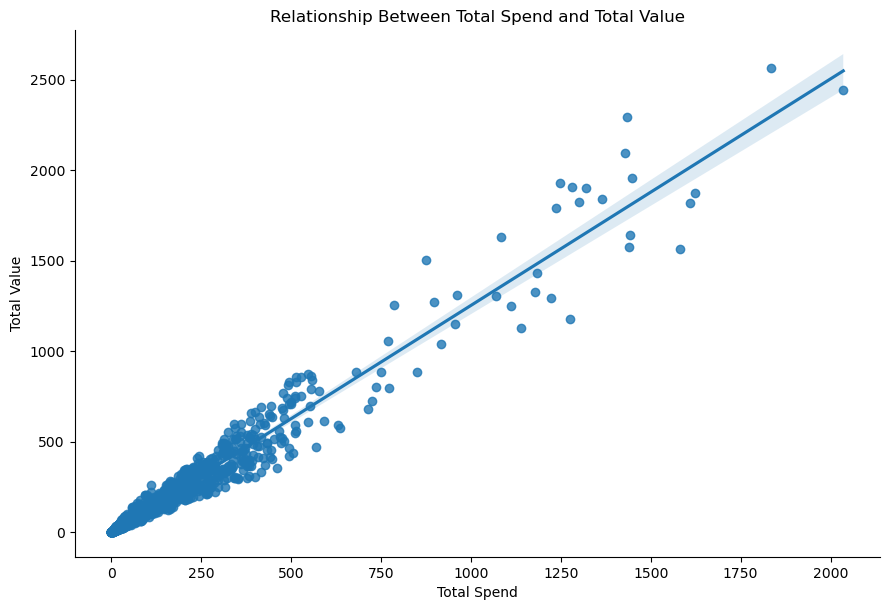

In [53]:
sns.lmplot(
    data=df,
    x="total_spend",
    y="total_value",
    height=6,
    aspect=1.5
)

plt.title("Relationship Between Total Spend and Total Value")
plt.xlabel("Total Spend")
plt.ylabel("Total Value")

plt.show()

The regression plot shows the relationship between advertising spend and total value.  
A positive trend indicates that higher ad spend is generally associated with higher total value.